# K-Means Clustering

This challenge will help you gain intuition on how a **K-means** clustering works.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

## 1) Generate Data

To make sure that our data actually contains relevant clusters, we will generate it ourselves.

To do so, we will use [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) from `sklearn`.  

We want a dataset with **500 observations**, **2 features** and **4 clusters**.  

We use *random_state=42* so that you can compare results with your buddy.

👇 Run the cell below to generate your data

In [30]:
random_state=42

# Generate data
X, y = make_blobs(n_samples=500, centers=4, random_state=random_state)
X[:,0]

array([ -7.68905443,  -9.57651383,   6.82968177,  -2.90130578,
        -5.67841327,  -6.04929137,  -6.27824322,  -6.60917037,
         3.57225841,  -7.50444577,   3.99330595,  -1.35060204,
         6.77291221,  -1.93830711,  -6.58985233,   5.69830332,
        -2.58120774,  -9.96104978,  -8.75604377,  -3.6155326 ,
         3.24131126,  -2.30033403,   5.2164358 ,  -7.27280373,
        -9.28476137,  -6.48517505,  -7.13460441,  -8.0525276 ,
        -8.57127749,  -1.55519586,  -6.91238046,  -1.6966718 ,
        -3.49973395,  -3.83738367,  -6.50848132,  -7.11857524,
         3.81765844,   3.03343252,  -8.88779147,  -7.85400536,
        -7.86923201,   5.94535764,  -2.72886951,  -1.71816568,
        -0.36525353,   6.28484655,   4.52755079,   5.35149371,
        -7.59247297,  -9.35593906,  -8.72050142,  -3.11090424,
        -9.67068333,  -6.36196817,   4.98163481,  -3.52202874,
        -2.40954626,  -8.92806345,  -6.59965856, -10.18277827,
        -9.35561621,  -1.99416236,  -7.5314633 ,  -8.74

❓ Make a scatter plot of your two features against each other  
❓ Color the points according to their corresponding  value in `y`

<details span="markdown">
    <summary>💡 Help</summary>

- Recall the color argument:
 - `c` for matplotlib  
 - `hue` for seaborn 

---
</details>

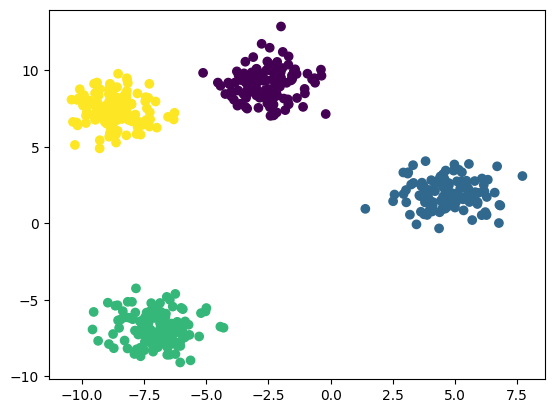

In [33]:
# YOUR CODE HERE
plt.scatter(X[:,0],X[:,1],c=y)

👆 You should see 4 distinct clusters, each with a different color.  

Training a KNN Classifier on `X` with `y` as target would give great results.

However today is about **Unsupervised Learning**

Let's assume that we never knew about `y` and only received `X` to work with.  

We only have 2 features and no target 😱  

**What can we can achieve with only `X` ?**  🤔

## 2) Apply K-Means

Your goal is to find the **number of clusters** that best matches the structure of your data.  


👉Import `KMeans` from `sklearn` and initiate a model with the parameters:
- `n_clusters=2`,
- `random_state=42`

❓Fit the model on your `X`  
❓ Get your predictions and store them in a `y_pred` variable.  

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


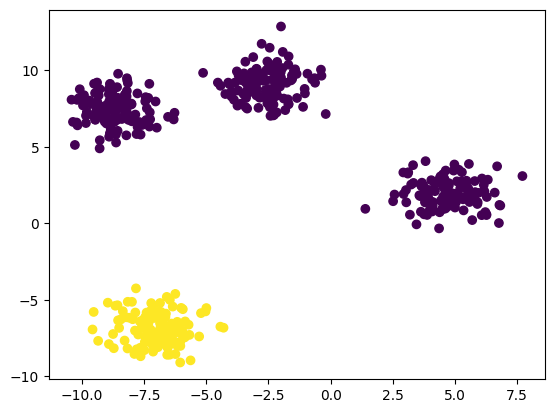

In [ ]:
# YOUR CODE HERE
from sklearn.cluster import KMeans

Kmeans_model = KMeans(n_clusters=2, random_state=42)

y_pred=Kmeans_model.fit_predict(X)


👆 The predictions are a vector of cluster assignment for each observation.  
With `n_clusters=2` each observation in `X` will be associated to either one of two clusters.

❓ Make a scatter plot of your two features against each other  
❓ Color the points according the predicted cluster in `y_pred`

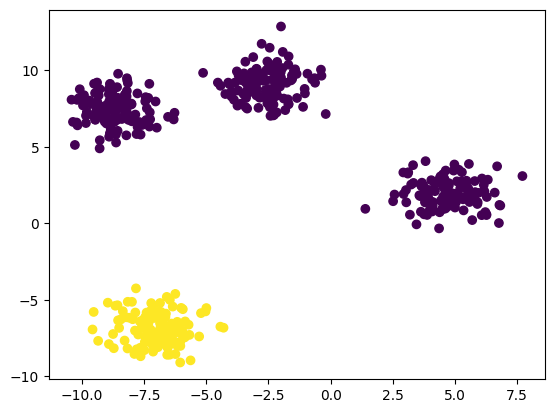

In [40]:
# YOUR CODE HERE
plt.scatter(X[:,0],X[:,1],c=y_pred)

👆 You can still see 4 distinct clusters, however the color only show 2. 😱

That's exactly what we asked for when giving `n_clusters=2` to our **Kmeans**.

We asked our algorithm to assign each observation to one of two centroids, hence one of two clusters only.

**This clustering around 2 centers is clearly no optimal, we can do better** 💪

### 🧪 Test your code

In [41]:
from nbresult import ChallengeResult

result = ChallengeResult('two_means', clusters=y_pred)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.10.6, pytest-8.0.0, pluggy-1.4.0 -- /home/lorezinn/.pyenv/versions/taxifare-env/bin/python3
cachedir: .pytest_cache
rootdir: /home/lorezinn/code/LorenzoZInna/05-ML/06-Unsupervised-Learning/data-image-compression-redo-2025-03-27/tests
plugins: anyio-3.7.1
collecting ... collected 2 items

test_two_means.py::TestTwoMeans::test_imbalanced_clusters PASSED         [ 50%]
test_two_means.py::TestTwoMeans::test_two_clusters PASSED                [100%]

============================== 2 passed in 0.72s ===============================


💯 You can commit your code:

git add tests/two_means.pickle

git commit -m 'Completed two_means step'

git push origin master



## 3) Find the optimal number of clusters  
*The Elbow Method*

Once fitted, the `KMeans` instance gains an attribute named `inertia_`.

It represents the **sum of squared distances of observations to their associated (closest) cluster center**. 

So the lower, the better.  

In [42]:
KMeans(n_clusters=2, random_state=random_state).fit(X).inertia_

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


15737.083577865003

👆 Think of this in comparison to the Sum of Squared Errors in a Linear Regression 👇  

- `SSE` of a `Linear Regression` 👉 `Sum of squared distances between observations and the regression line`  

- `Inertia` of a `KMeans Clustering` 👉 `Sum of squared distances between observations and their closest centroid`

One way for us to find the optimal number of clusters is a heuristic: the **Elbow Method**.  

We have to try several number of clusters and look at the inertia obtained for each one.  

Let's do it to get the intuition! ⚙️🧠

❓ Fit a `KMeans` for every number of clusters between 1 and 10, for each one, save the inertia in a list `wcss`

In [59]:
# Apply the elbow method to find the optimal number of clusters.
from sklearn.metrics import silhouette_score
#lookup https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score
#for automatic inflection point evaluation in elbow method
silhouette=[]
n_list = []
wcss =[]
clusters = list(range(2, 11))
for n in clusters:
    model=KMeans(n_clusters=n, random_state=random_state)
    n_list.append(n)
    wcss.append(model.fit(X).inertia_)
    label = model.labels_
    silhouette.append(silhouette_score(X, label, metric='euclidean'))

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/clus

In [60]:
maxsil=max(silhouette)
indexk=silhouette.index(maxsil)
clusters[indexk]

4

❓  Plot the inertias in `wcss` against their corresponding number of clusters ❓

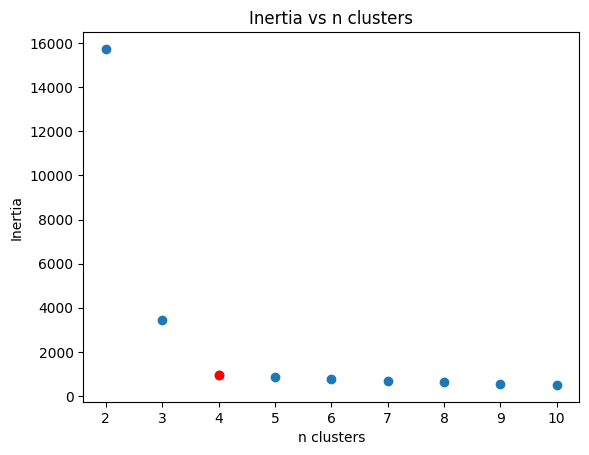

In [62]:
# YOUR CODE HERE
maxsil=max(silhouette)
silhouette.index(maxsil)
plt.scatter(n_list,wcss)
plt.scatter(clusters[indexk],wcss[indexk],c="r")
plt.title("Inertia vs n clusters")
plt.xlabel("n clusters")
plt.ylabel("Inertia")
plt.show()


👆 We clearly see an Elbow at 4 clusters.  

## 3) K-Means with optimal clusters

With the optimal number of clusters know, it's time to fit a last `KMeans`.

❓ Fit a `KMeans` with `n_clusters=4` on your `X`, store the predictions in `y_pred`  

❓ Make a scatter plot of your two features against each other, and color the points  according the predicted cluster in `y_pred`

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[0 1 2 3] [125 125 125 125]


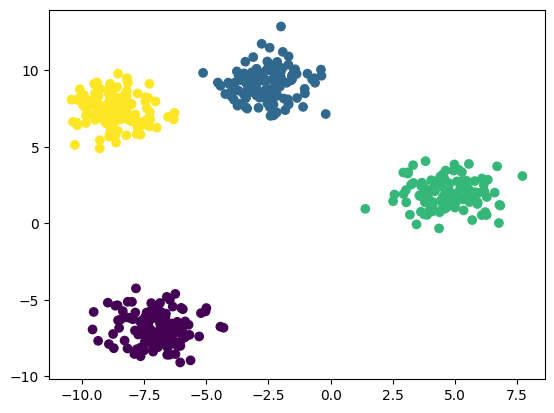

In [66]:
# YOUR CODE HERE
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=4)
y_pred=kmeans_model.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=y_pred)
# Step 4: Get the cluster labels (each pixel's cluster assignment)
labels = kmeans_model.labels_

# Step 5: Count the number of pixels in each cluster
unique, counts = np.unique(labels, return_counts=True)
print(unique,counts)

That is clustering at its best 	🏆  
We successfully identified **4 clusters** among our observations.  

**Notes:** Scaling features before clustering is not always necessary, but it rarely hurts 😇  
You can check these [detailed answers](https://datascience.stackexchange.com/questions/6715/is-it-necessary-to-standardize-your-data-before-clustering) to go further.

🏁 **Don't forget to push your notebook.**  

Proceed the challenges of the day and come back here if you have time 😉

## 4 - Optional) Hierarchical Clustering

An other method that will help us find the optimal number of clusters is called [Hierarchical Clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering).

👉 Plot the **dendrogram** of the hierarchical clustering.

You will need the help of two scipy classes found in its [cluster.hierarchy](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html) module:
- [linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage)
- [dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html#scipy.cluster.hierarchy.dendrogram)

The linkage actually does the hierarchical clustering with a bottom-up approach: each observation starts in its own cluster.  

At each iteration the algorithm will choose clusters to merge, the last iteration occurs when a single cluster is formed.  

Here we will use Ward's method, which minimizes the total within-cluster variance.  
So at each iteration the algorithm will find the pair of clusters which merging will minimize the within-cluster variance. 

A dendrogram is just a diagram representing a tree-like structure, it allows us to visualize the linkage.  

<br>
<details span="markdown">
    <summary>💡 Solution</summary>

```python
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(Z, color_threshold=50)
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.xticks([]);
```
---
</details>


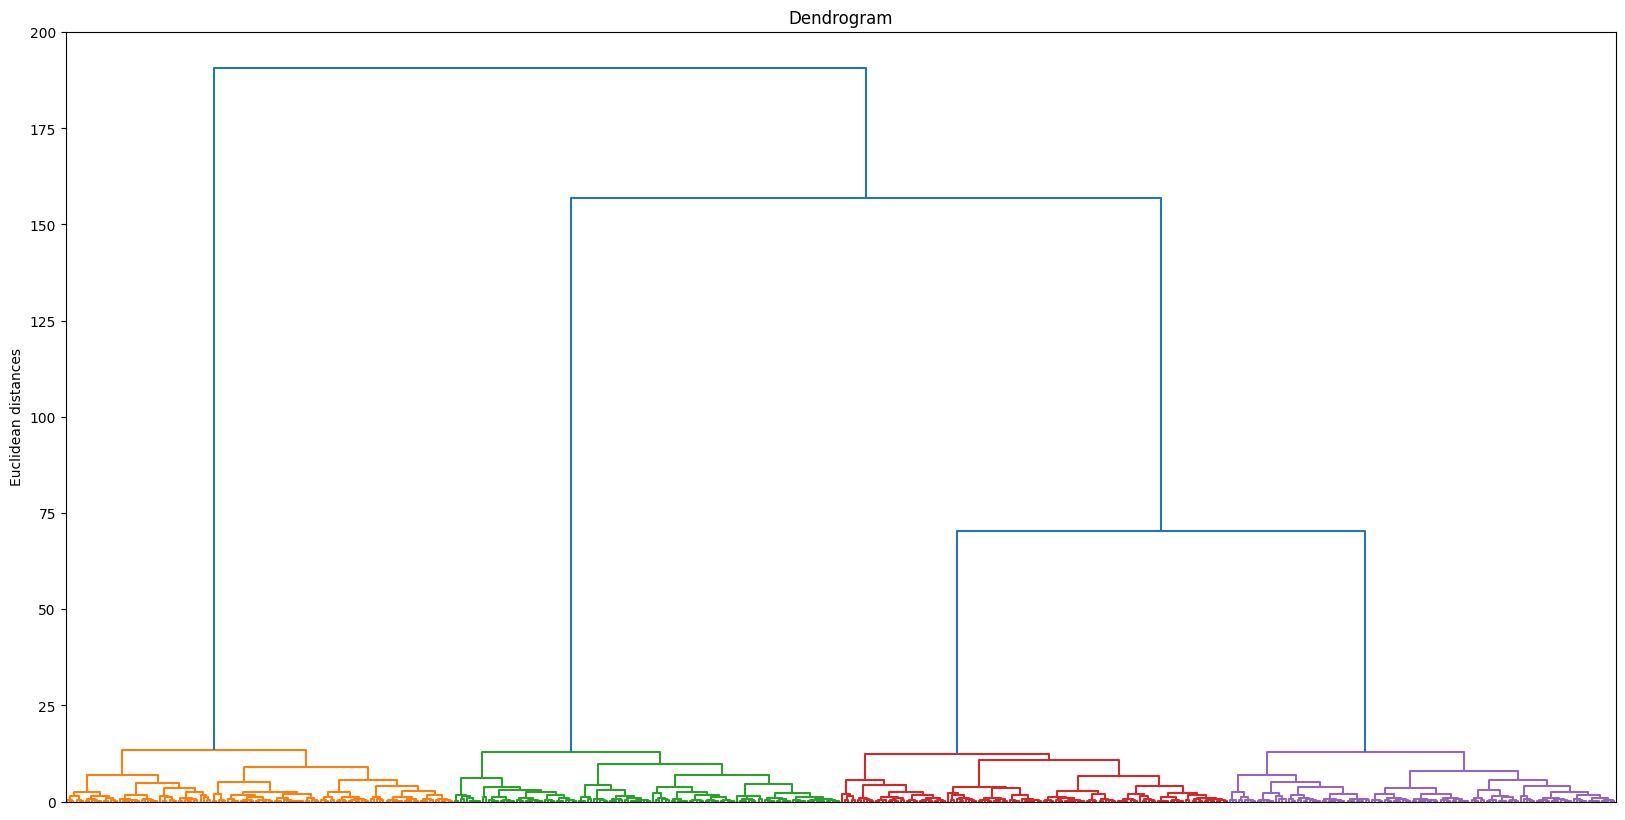

In [63]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(Z, color_threshold=50)
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.xticks([]);

We can still see 4 distinct clusters  

🤔 Why did we used the *Ward method* here?

💡 Because it is the same objective function than K-means, which tries to minimize the inertia (i.e. the within cluster variance)

### Insights on Hierarchical Clustering

👉 Watch this video to better understand hierarchical clustering: https://www.youtube.com/watch?v=7xHsRkOdVwo

👉 Hierarchical clustering is considered *greedy*, meaning that it is likely to yield a local optima and miss the big picture

👉 Note that there exist other clustering linkages (ie. other ways to measure distance between two clusters) <img src=https://editor.analyticsvidhya.com/uploads/40351linkages.PNG>